# BNPL Customer Analysis

## Цель проекта
Определить, какие характеристики клиентов и особенности использования BNPL связаны с наличием просроченных платежей, чтобы улучшить сегментацию клиентов и персонализацию коммуникаций.

- подготовка данных;
- анализ профиля пользователя;
- анализ BNPL-поведение;
- связи между характеристиками клиентов и использованием сервиса;
- анализ пользователей с просроченными платежами и без;
- выводы и рекомендации.

> **Примечание:** данные синтетические. `Default_Risk` рассчитан на основе `debt-to-income ratio`, `credit_score` и `late_payment`, поэтому он не используется как самостоятельный объект анализа.


In [1]:
import pandas as pd

In [2]:
bnpl = pd.read_csv("BNPL_Financial_Default_Risk_Dataset.csv", index_col="Customer_ID")

In [3]:
bnpl.head()

,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
Customer_ID,,,,,,,,,,
C00001,29,Employed,73405.0,637.0,2,193,No,Fashion,118,Low
C00002,64,Employed,53732.0,815.0,0,0,No,Electronics,662,Low
C00003,26,Freelancer,69930.0,723.0,2,273,No,Fashion,76,Low
C00004,19,Employed,96941.0,716.0,3,421,No,Home/Furniture,449,Low
C00005,55,Student,15959.0,675.0,2,145,No,Travel,974,Low


# 1. Подготовка данных к анализу


In [4]:
bnpl.shape
bnpl.isna().sum()
bnpl.index.duplicated().sum()
bnpl.info()
bnpl.describe(include="all")

<class 'pandas.DataFrame'>
Index: 10000 entries, C00001 to C10000
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              10000 non-null  int64  
 1   Employment_Status                10000 non-null  str    
 2   Income_USD                       9695 non-null   float64
 3   Credit_Score                     9702 non-null   float64
 4   Total_BNPL_Active_Loans          10000 non-null  int64  
 5   Total_BNPL_Debt_USD              10000 non-null  int64  
 6   Late_Payment_History             10000 non-null  str    
 7   Shopping_Category_Most_Frequent  10000 non-null  str    
 8   Average_Transaction_Value_USD    10000 non-null  int64  
 9   Default_Risk                     10000 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 1.1 MB


,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
count,10000.000000,10000,9695.000000,9702.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,4,NaN,NaN,NaN,NaN,2,5,NaN,3
top,NaN,Employed,NaN,NaN,NaN,NaN,No,Fashion,NaN,Low
freq,NaN,6029,NaN,NaN,NaN,NaN,7524,4012,NaN,8801
mean,34.248300,NaN,53981.142651,663.671408,2.317000,348.805100,NaN,NaN,331.807700,NaN
std,12.911441,NaN,29797.373960,76.221869,1.854469,315.096249,NaN,NaN,264.360624,NaN
min,18.000000,NaN,5000.000000,300.000000,0.000000,0.000000,NaN,NaN,10.000000,NaN
25%,23.000000,NaN,21996.500000,620.000000,1.000000,142.000000,NaN,NaN,98.000000,NaN
50%,31.000000,NaN,58596.000000,673.000000,2.000000,262.500000,NaN,NaN,294.500000,NaN
75%,43.000000,NaN,77073.500000,717.000000,3.000000,467.000000,NaN,NaN,515.000000,NaN


В датасете 10 000 наблюдений. Пропуски присутствуют в `income` и `credit_score` и составляют около 3% значений. Реальные значения неизвестны, поэтому оставим `NaN`.


In [5]:
bnpl = bnpl.rename(
    columns={
        "Age": "age",
        "Employment_Status": "status",
        "Income_USD": "income",
        "Credit_Score": "credit_score",
        "Total_BNPL_Active_Loans": "active_loans",
        "Total_BNPL_Debt_USD": "dept",
        "Late_Payment_History": "late_payment",
        "Shopping_Category_Most_Frequent": "shopping_category",
        "Average_Transaction_Value_USD": "avg_transaction_value",
        "Default_Risk": "default_risk",
    }
)

bnpl.index.name = "customer_id"

In [6]:
bnpl["age"] = bnpl["age"].astype("int8")
bnpl["income"] = bnpl["income"].astype("Int32")
bnpl["credit_score"] = bnpl["credit_score"].round().astype("Int16")
bnpl["active_loans"] = bnpl["active_loans"].astype("int8")
bnpl["dept"] = bnpl["dept"].astype("int16")
bnpl["avg_transaction_value"] = bnpl["avg_transaction_value"].astype("int16")

for column in ["status", "late_payment", "shopping_category", "default_risk"]:
    bnpl[column] = bnpl[column].astype("category")

In [7]:
bnpl["income_group"] = pd.cut(
    bnpl["income"],
    bins=[0, 20000, 40000, 60000, 80000, 100000, float("inf")],
    labels=["<20k", "20k-40k", "40k-60k", "60k-80k", "80k-100k", "100k+"],
)

In [8]:
bnpl["age_group"] = pd.cut(
    bnpl["age"],
    bins=[18, 25, 35, 50, 71],
    labels=["18-24", "25-34", "35-49", "50-70"],
    include_lowest=True,
    right=False,
)

# 2. Демография и финансовый профиль


## Возраст


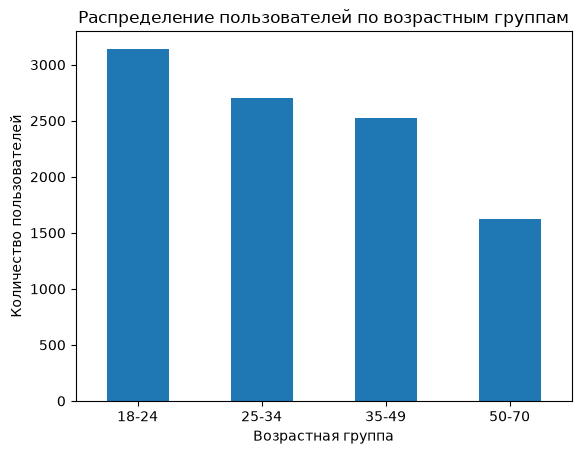

In [9]:
age_group_counts = bnpl["age_group"].value_counts().sort_index()
age_group_counts

age_gr = age_group_counts.plot(kind="bar")
age_gr.set_xlabel("Возрастная группа")
age_gr.set_ylabel("Количество пользователей")
age_gr.set_title("Распределение пользователей по возрастным группам")
age_gr.tick_params(axis="x", rotation=0)

## Статус занятости


Text(0.5, 1.0, 'Распределение пользователей по статусу занятости')

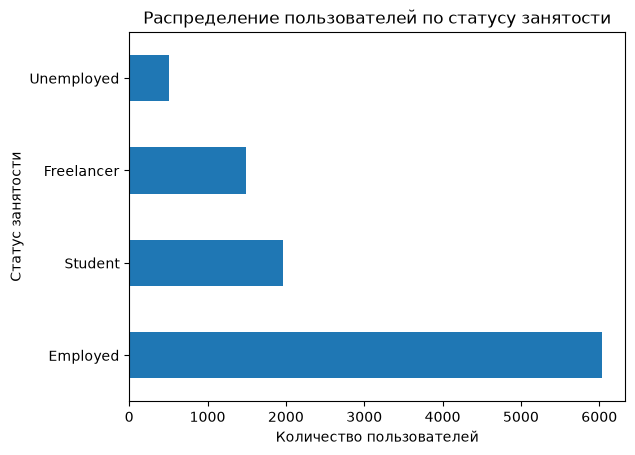

In [10]:
status_gr = bnpl["status"].value_counts().plot(kind="barh")

status_gr.set_xlabel("Количество пользователей")
status_gr.set_ylabel("Статус занятости")
status_gr.set_title("Распределение пользователей по статусу занятости")

In [11]:
status_summary = pd.DataFrame(
    {
        "count": bnpl["status"].value_counts(),
        "share": bnpl["status"].value_counts(normalize=True),
    }
)

status_summary.style.format({"count": "{:.0f}", "share": "{:.1%}"})

,count,share
status,,
Employed,6029,60.3%
Student,1968,19.7%
Freelancer,1495,14.9%
Unemployed,508,5.1%


## Доход


In [12]:
income_summary = pd.DataFrame(
    {
        "count": bnpl["income_group"].value_counts().sort_index(),
        "share": bnpl["income_group"].value_counts(normalize=True).sort_index(),
    }
)

income_summary.style.format({"count": "{:.0f}", "share": "{:.1%}"})

,count,share
income_group,,
<20k,2214,22.8%
20k-40k,972,10.0%
40k-60k,1863,19.2%
60k-80k,2578,26.6%
80k-100k,1621,16.7%
100k+,447,4.6%


## Credit score


In [13]:
bnpl["credit_score"].describe()

count        9702.0
mean     663.671408
std       76.221869
min           300.0
25%           620.0
50%           673.0
75%           717.0
max           850.0
Name: credit_score, dtype: Float64

Медианный credit score — 673 балла. Значения показателя заметно различаются между пользователями.

# 3. BNPL-поведение


## Количество активных займов


In [14]:
bnpl["active_loans"].value_counts().sort_index()

active_loans
0      998
1     2998
2     2497
3     1503
4      803
5      513
6      290
7      200
8       89
9       50
10      59
Name: count, dtype: int64

In [15]:
bnpl["active_loans"].describe()

count    10000.000000
mean         2.317000
std          1.854469
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: active_loans, dtype: float64

В среднем у пользователей 2 BNPL-займа: медиана — 2, а у 75% пользователей их не больше 3. Пользователи с большим количеством активных займов встречаются значительно реже.

In [16]:
high_loans = bnpl[bnpl["active_loans"] >= 6]
high_loans.describe()

,age,income,credit_score,active_loans,dept,avg_transaction_value
count,688.000000,665.0,675.0,688.000000,688.000000,688.000000
mean,33.813953,54057.897744,667.89037,7.110465,1073.795058,340.143895
std,12.633116,29962.498534,75.791666,1.266294,402.525796,268.673784
min,18.000000,5000.0,395.0,6.000000,0.000000,10.000000
25%,23.000000,23007.0,619.5,6.000000,795.000000,105.000000
50%,31.500000,57627.0,676.0,7.000000,1049.000000,307.500000
75%,43.000000,75437.0,719.0,8.000000,1303.250000,528.250000
max,64.000000,133107.0,850.0,10.000000,2731.000000,1347.000000


Пользователи с 6+ активными BNPL-займами по возрасту, доходу, кредитному рейтингу и средней сумме транзакции почти не отличаются от общей выборки. При этом их общий BNPL-долг примерно в три раза выше.

Это довольно ожидаемо — чем больше активных займов, тем выше суммарный долг.

## BNPL-задолженность


In [17]:
bnpl["dept"].describe()

count    10000.000000
mean       348.805100
std        315.096249
min          0.000000
25%        142.000000
50%        262.500000
75%        467.000000
max       2731.000000
Name: dept, dtype: float64

Text(0.5, 1.0, 'Распределение задолженности по BNPL')

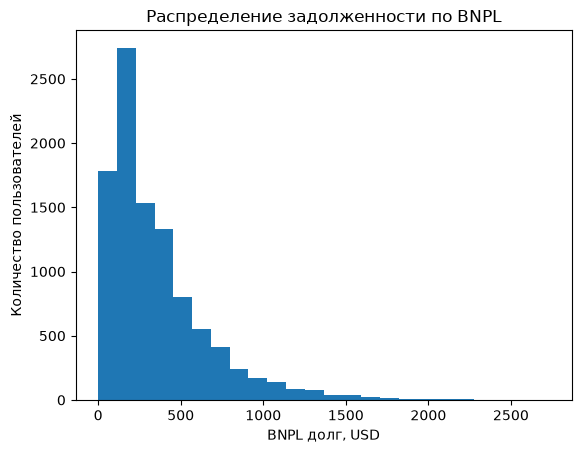

In [18]:
ax_debt = bnpl["dept"].plot(kind="hist", bins=24)

ax_debt.set_xlabel("BNPL долг, USD")
ax_debt.set_ylabel("Количество пользователей")
ax_debt.set_title("Распределение задолженности по BNPL")

Медиана составляет около 263 USD, у 75% пользователей долг не превышает 467 USD. При этом встречаются отдельные пользователи с долгом более 2000 USD.

## Средняя сумма транзакции


In [19]:
bnpl["avg_transaction_value"].describe()

count    10000.000000
mean       331.807700
std        264.360624
min         10.000000
25%         98.000000
50%        294.500000
75%        515.000000
max       1420.000000
Name: avg_transaction_value, dtype: float64

Text(0.5, 1.0, 'Распределение средней суммы транзакции')

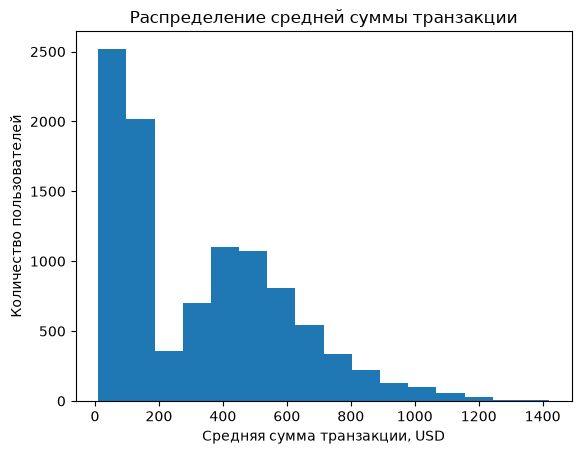

In [20]:
ax_avg_tr = bnpl["avg_transaction_value"].plot(kind="hist", bins=16)
ax_avg_tr.set_xlabel("Средняя сумма транзакции, USD")
ax_avg_tr.set_ylabel("Количество пользователей")
ax_avg_tr.set_title("Распределение средней суммы транзакции")

У 75% пользователей средняя сумма транзакции не превышает 515 USD. При этом в выборке есть пользователи с существенно более высокими значениями.


## Категории покупок


In [21]:
c_counts = bnpl["shopping_category"].value_counts()

sc_percent = bnpl["shopping_category"].value_counts(normalize=True)

sc_summary = pd.DataFrame({"counts": c_counts, "percent": sc_percent})

sc_summary = sc_summary.style.format({"counts": "{:.0f}", "percent": "{:.1%}"})
sc_summary

,counts,percent
shopping_category,,
Fashion,4012,40.1%
Electronics,2991,29.9%
Home/Furniture,1512,15.1%
Travel,971,9.7%
Groceries/Essentials,514,5.1%


# 4. Связи между характеристиками


## Возраст и использование BNPL


In [22]:
age_summary = (
    bnpl.groupby("age_group", observed=True)
    .agg(
        avg_active_loans=("active_loans", "mean"),
        median_active_loans=("active_loans", "median"),
        avg_dept=("dept", "mean"),
        median_dept=("dept", "median"),
    )
    .round(1)
)
age_summary

,avg_active_loans,median_active_loans,avg_dept,median_dept
age_group,,,,
18-24,2.3,2.0,348.0,266.0
25-34,2.3,2.0,351.6,264.0
35-49,2.3,2.0,351.4,261.0
50-70,2.3,2.0,341.8,254.5


Заметной зависимости количества активных займов и размера BNPL-долга от возраста не наблюдается.

## Доход и использование BNPL


In [23]:
income_summary = (
    bnpl.groupby("income_group", observed=True)
    .agg(
        avg_active_loans=("active_loans", "mean"),
        median_active_loans=("active_loans", "median"),
        avg_dept=("dept", "mean"),
        median_dept=("dept", "median"),
    )
    .round(1)
)
income_summary

,avg_active_loans,median_active_loans,avg_dept,median_dept
income_group,,,,
<20k,2.3,2.0,344.8,262.0
20k-40k,2.3,2.0,350.4,267.0
40k-60k,2.3,2.0,355.8,255.0
60k-80k,2.3,2.0,343.5,257.5
80k-100k,2.3,2.0,347.1,266.0
100k+,2.4,2.0,369.1,281.0


Заметной зависимости количества активных займов и BNPL-долга от уровня дохода не наблюдается.
Пользователи с доходом выше 100 тыс. USD имеют немного более высокий средний и медианный долг, однако разница невелика

## Credit score, количество займов и задолженность


In [24]:
corr = bnpl[["credit_score", "active_loans", "dept"]].corr()


def highlight_corr(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    styles.loc["active_loans", "dept"] = "background-color: yellow; font-weight: bold"
    styles.loc["dept", "active_loans"] = "background-color: yellow; font-weight: bold"
    return styles


corr.style.apply(highlight_corr, axis=None)

,credit_score,active_loans,dept
credit_score,1.000000,0.014751,0.006752
active_loans,0.014751,1.000000,0.886467
dept,0.006752,0.886467,1.000000


Credit score практически не связан ни с количеством активных займов, ни с размером BNPL-задолженности. При этом количество активных займов и общий долг имеют сильную положительную связь, что ожидаемо: больше активных обязательств обычно означает большую совокупную задолженность.


## Категория покупок и средняя сумма транзакции


In [25]:
category_summary = (
    bnpl.groupby("shopping_category", observed=True)
    .agg(
        avg_transaction=("avg_transaction_value", "mean"),
        median_transaction=("avg_transaction_value", "median"),
        sum_avg_transaction=("avg_transaction_value", "sum"),
    )
    .sort_values(by="avg_transaction", ascending=False)
)
category_summary

,avg_transaction,median_transaction,sum_avg_transaction
shopping_category,,,
Travel,804.003090,804.0,780687
Electronics,504.462053,506.0,1508846
Home/Furniture,399.130291,401.0,603485
Fashion,99.562064,99.0,399443
Groceries/Essentials,49.836576,51.0,25616


Text(0.5, 1.0, 'Средняя сумма транзакции по категориям')

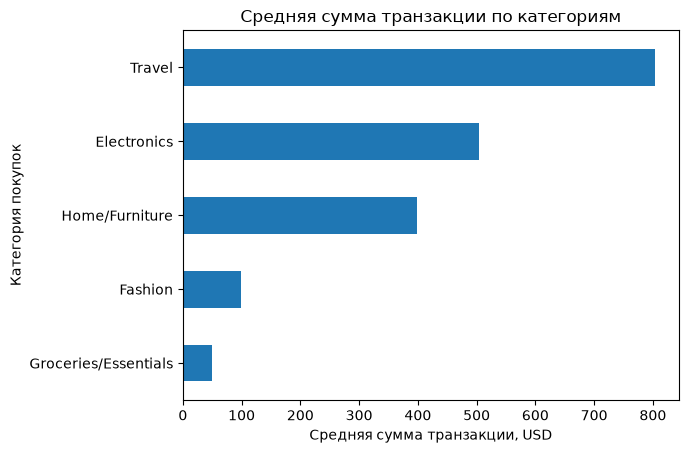

In [26]:
category_chart = category_summary["avg_transaction"].sort_values().plot(kind="barh")

category_chart.set_xlabel("Средняя сумма транзакции, USD")
category_chart.set_ylabel("Категория покупок")
category_chart.set_title("Средняя сумма транзакции по категориям")

Travel имеет самый высокий средний чек — около 804 USD, хотя эта категория охватывает относительно небольшую долю пользователей (около 9,7%). Fashion является самой популярной категорией.

Сумма пользовательских средних чеков не является фактическим оборотом категории, поскольку в датасете отсутствует количество транзакций каждого пользователя.


# 5. Анализ просроченных платежей


## Общая доля просрочек


In [27]:
l_counts = bnpl["late_payment"].value_counts()
l_percent = bnpl["late_payment"].value_counts(normalize=True)

lp_summary = pd.DataFrame({"counts": l_counts, "percent": l_percent})
lp_summary.style.format({"counts": "{:.0f}", "percent": "{:.1%}"})

,counts,percent
late_payment,,
No,7524,75.2%
Yes,2476,24.8%


Большинство пользователей (около 75%) не имеют просроченных платежей. Примерно у каждого четвертого пользователя просрочки были.

## Возраст


In [28]:
age_late = pd.crosstab(
    bnpl["age_group"], bnpl["late_payment"], normalize="index"
).style.format("{:.1%}")
age_late

late_payment,No,Yes
age_group,,
18-24,75.0%,25.0%
25-34,75.5%,24.5%
35-49,75.3%,24.7%
50-70,75.2%,24.8%


Доля пользователей с просрочками практически одинакова во всех возрастных группах — около 25%.

## Доход


In [29]:
income_late = pd.crosstab(bnpl["income_group"], bnpl["late_payment"], normalize="index")
income_late.style.background_gradient(subset=["Yes"], cmap="Reds").format("{:.1%}")

late_payment,No,Yes
income_group,,
<20k,53.6%,46.4%
20k-40k,70.3%,29.7%
40k-60k,82.5%,17.5%
60k-80k,82.7%,17.3%
80k-100k,84.4%,15.6%
100k+,86.8%,13.2%


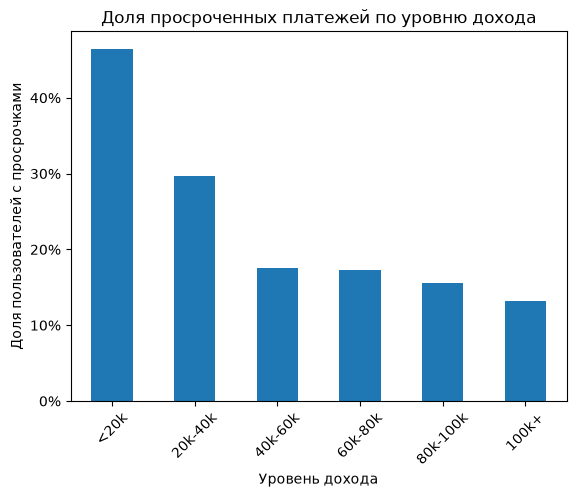

In [30]:
from matplotlib.ticker import PercentFormatter

income_late_chart = income_late["Yes"].plot(kind="bar")

income_late_chart.set_xlabel("Уровень дохода")
income_late_chart.set_ylabel("Доля пользователей с просрочками")
income_late_chart.set_title("Доля просроченных платежей по уровню дохода")
income_late_chart.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
income_late_chart.tick_params(axis="x", rotation=45)

В выборке наблюдается выраженная обратная связь между уровнем дохода и наличием просрочек: чем выше доход пользователя, тем ниже доля клиентов с Late Payment. В группе с доходом ниже 20 тыс. USD просрочки встречаются у 46.4% пользователей, тогда как в группе 100 тыс. USD и выше — у 13.2%.

## Статус занятости


In [43]:
status_late = pd.crosstab(
    bnpl["status"], bnpl["late_payment"], normalize="index"
).sort_values(by="Yes", ascending=False)
status_late.style.format("{:.1%}")

late_payment,No,Yes
status,,
Unemployed,39.0%,61.0%
Student,55.8%,44.2%
Freelancer,73.6%,26.4%
Employed,85.0%,15.0%


Просрочки чаще встречаются среди безработных и студентов и заметно реже — среди работающих пользователей. Статус занятости связан с наличием просроченных платежей.


## Credit score


In [42]:
score_late = bnpl.groupby("late_payment", observed=True).agg(
    avg_credit_score=("credit_score", "mean"),
    median_credit_score=("credit_score", "median"),
)

score_late.style.format("{:.1f}")

,avg_credit_score,median_credit_score
late_payment,,
No,682.6,687.0
Yes,606.3,614.0


Пользователи с просрочками имеют более низкий средний credit score: 606 против 683.

## Количество активных займов


In [33]:
active_loans_late = bnpl.groupby("late_payment", observed=True).agg(
    avg_active_loans=("active_loans", "mean"),
    median_active_loans=("active_loans", "median"),
)
active_loans_late

,avg_active_loans,median_active_loans
late_payment,,
No,2.317517,2.0
Yes,2.315428,2.0


Количество активных BNPL-займов практически не различается между пользователями с просрочками и без них.

## Размер BNPL-задолженности


In [34]:
dept_late = bnpl.groupby("late_payment", observed=True).agg(
    avg_dept=("dept", "mean"), median_dept=("dept", "median")
)

dept_late.style.format("{:.1f}")

,avg_dept,median_dept
late_payment,,
No,347.5,261.0
Yes,352.8,267.5


Размер BNPL-долга практически не различается между пользователями с просрочками и без них.

## Средняя сумма транзакции


In [41]:
avg_trans_late = bnpl.groupby("late_payment", observed=True).agg(
    avg_trans=("avg_transaction_value", "mean"),
    median_trans=("avg_transaction_value", "median"),
)

avg_trans_late.style.format("{:.1f}")

,avg_trans,median_trans
late_payment,,
No,329.8,287.5
Yes,337.9,311.5


У пользователей с просрочками медианный средний чек выше примерно на 8%, при этом среднее значение отличается незначительно.

## Категория покупок


In [36]:
category_late = pd.crosstab(
    bnpl["shopping_category"], bnpl["late_payment"], normalize="index"
)
category_late.style.background_gradient(subset=["Yes"], cmap="Reds").format("{:.1%}")

late_payment,No,Yes
shopping_category,,
Electronics,75.1%,24.9%
Fashion,75.8%,24.2%
Groceries/Essentials,75.3%,24.7%
Home/Furniture,74.5%,25.5%
Travel,74.6%,25.4%


Категория покупок почти не влияет на долю просрочек: во всех категориях показатель находится примерно на уровне общего значения по выборке — около 25%.
    

# 6. Ключевые выводы и рекомендации

### Ключевые выводы
- Наиболее заметные различия между пользователями с просрочками и без них наблюдаются по уровню дохода, статусу занятости и credit score.
- С ростом дохода доля пользователей с просрочками снижается: с 46,4% в группе `<20k` до 13,2% в группе `100k+`.
- Среди работающих пользователей доля просрочек составляет около 15%, тогда как среди безработных — около 61%.
- Пользователи с просрочками имеют более низкий средний credit score: около 606 против 683.
- Возраст, количество активных займов, размер BNPL-задолженности и категория покупок почти не различают пользователей с просрочками и без них.
- У пользователей с просрочками медианный средний чек примерно на 8% выше.

### Рекомендации
- При сегментации клиентов учитывать уровень дохода, статус занятости и credit score.
- Количество активных займов, размер BNPL-задолженности и категорию покупок не рекомендуется использовать как основные признаки для разделения пользователей по наличию просрочек, поскольку в выборке различий не обнаружено.